# UST (Unified Source Theory) — QuTiP Deneyi
**Niyazi ÖCAL — Patent No: 2026/003258**

Bu notebook JupyterLite'ta doğrudan çalışır. Kurulum gerektirmez.

## Ne test ediyoruz?
- **T1:** κ·dt = π·Ns_q (evrensel stabilizasyon hızı)
- **T2:** F_Om ≥ (√3−1)/2 (Omnium alt sınırı)
- **T3:** S_Om analitik formül
- **T10:** Omnium tünelleme T_Om ≈ 1 − Ns_q

In [14]:
# ── Adım 2: Temel sabitler
import numpy as np
import matplotlib.pyplot as plt
import warnings
import qutip as qt
warnings.filterwarnings('ignore')

# UST evrensel sabiti
phi   = (1 + np.sqrt(5)) / 2        # Altın oran φ
e_val = np.e                         # Euler sayısı
alpha = 1 / 137.035999               # İnce yapı sabiti α
Ns_q  = 2 * np.pi**2 * phi * e_val * alpha
pi_Ns = np.pi * Ns_q

print('=' * 50)
print('UST EVRENSEİ SABİTLER')
print('=' * 50)
print(f'Ns_q        = {Ns_q:.10f}')
print(f'π·Ns_q      = {pi_Ns:.10f}')
print(f'1/Ns_q      = {1/Ns_q:.10f}')
print(f'(√3−1)/2    = {(np.sqrt(3)-1)/2:.10f}  ← T2 alt sınırı')
print(f'1 − Ns_q    = {1-Ns_q:.10f}  ← tünelleme T_Om tahmini')
print(f'Ns_q/(1-Ns_q) = {Ns_q/(1-Ns_q):.6f} ≈ √3 = {np.sqrt(3):.6f}')

UST EVRENSEİ SABİTLER
Ns_q        = 0.6335445992
π·Ns_q      = 1.9903390586
1/Ns_q      = 1.5784208424
(√3−1)/2    = 0.3660254038  ← T2 alt sınırı
1 − Ns_q    = 0.3664554008  ← tünelleme T_Om tahmini
Ns_q/(1-Ns_q) = 1.728845 ≈ √3 = 1.732051


In [15]:
# ── Adım 3: QuTiP ile Lindblad simülasyonu
import qutip as qt

# Parametreler
gamma   = 0.05      # dekoherans hızı
dt      = 0.01      # zaman adımı
kappa   = pi_Ns / dt  # UST optimal κ
sigma   = 1.0
N       = 1000
N_train = 500

np.random.seed(42)
p_noise = sigma * np.random.randn(N)
p_train = p_noise[:N_train]
p_test  = p_noise[N_train:]

# Başlangıç durumu |+⟩
psi0 = (qt.basis(2,0) + qt.basis(2,1)).unit()
rho0 = psi0 * psi0.dag()

# Pauli operatörleri
sz = qt.sigmaz()
I2 = qt.identity(2)

# Fidelity fonksiyonu
def fidelity(psi, rho):
    return float(np.real((psi.dag() * rho * psi).tr()))

# Von Neumann entropi
def entropy(rho):
    return float(qt.entropy_vn(rho, base=np.e))

# DFS öğren
def compute_dfs(rho0, p_train, gamma, dt):
    L_d = np.sqrt(gamma * dt) * sz
    E_sum = qt.Qobj(np.zeros((2,2), dtype=complex), dims=[[2],[2]])
    for p in p_train:
        U = (-1j * p * sz / 2).expm()
        rk = U * rho0 * U.dag()
        # Lindblad adımı
        LdL = L_d.dag() * L_d
        drho = L_d * rk * L_d.dag() - 0.5 * (LdL * rk + rk * LdL)
        rk = rk + drho
        # Fizikselleştir
        rk = (rk + rk.dag()) / 2
        vals, vecs = rk.eigenstates()
        vals = np.maximum(vals.real, 0)
        rk = sum(v * vecs[i] * vecs[i].dag() for i, v in enumerate(vals))
        tr = rk.tr().real
        if tr > 1e-10:
            rk = rk / tr
        E_sum = E_sum + rk
    rho_avg = E_sum / N_train
    vals, vecs = rho_avg.eigenstates()
    idx = np.argsort(vals.real)[::-1]
    return vecs[idx[0]], vecs[idx[1]]

psi_DFS, psi_PERP = compute_dfs(rho0, p_train, gamma, dt)
print(f'DFS öğrenildi:')
print(f'  |ψ_DFS⟩ = [{psi_DFS[0][0][0]:.4f}, {psi_DFS[1][0][0]:.4f}]')
print('DFS hazır ✓')

DFS öğrenildi:


IndexError: invalid index to scalar variable.

In [ ]:
# ── Adım 4: Simülasyon — DFS vs Standart

L_dek  = np.sqrt(gamma * dt) * sz
L_kor  = np.sqrt(kappa * dt) * psi_DFS * psi_PERP.dag()
LdL_d  = L_dek.dag() * L_dek
LdL_k  = L_kor.dag() * L_kor

def lindblad_step(rho, ops):
    drho = qt.Qobj(np.zeros((2,2), dtype=complex), dims=[[2],[2]])
    for L in ops:
        LdL = L.dag() * L
        drho += L * rho * L.dag() - 0.5 * (LdL * rho + rho * LdL)
    return drho

def make_physical(rho):
    rho = (rho + rho.dag()) / 2
    vals, vecs = rho.eigenstates()
    vals = np.maximum(vals.real, 0)
    rho = sum(v * vecs[i] * vecs[i].dag() for i, v in enumerate(vals))
    tr = rho.tr().real
    if tr > 1e-10:
        rho = rho / tr
    return rho

rho_std = rho0.copy()
rho_dfs = rho0.copy()
fid_std_arr = []
fid_dfs_arr = []
S_dfs_arr   = []

for p in p_test:
    U = (-1j * p * sz / 2).expm()
    
    # Standart
    rho_std = U * rho_std * U.dag()
    rho_std = rho_std + lindblad_step(rho_std, [L_dek])
    rho_std = make_physical(rho_std)
    
    # DFS+UST
    rho_dfs = U * rho_dfs * U.dag()
    rho_dfs = rho_dfs + lindblad_step(rho_dfs, [L_dek, L_kor])
    rho_dfs = make_physical(rho_dfs)
    
    fid_std_arr.append(fidelity(psi0, rho_std))
    fid_dfs_arr.append(fidelity(psi0, rho_dfs))
    S_dfs_arr.append(entropy(rho_dfs))

fid_std_arr = np.array(fid_std_arr)
fid_dfs_arr = np.array(fid_dfs_arr)
S_dfs_arr   = np.array(S_dfs_arr)

F_std = np.mean(fid_std_arr[-50:])
F_dfs = np.mean(fid_dfs_arr[-50:])
S_son = np.mean(S_dfs_arr[-50:])

print('=' * 50)
print('T1 — DFS+Ns vs Standart')
print('=' * 50)
print(f'F_std (son 50) = {F_std:.6f}')
print(f'F_dfs (son 50) = {F_dfs:.6f}')
print(f'İyileşme       = +{(F_dfs-F_std)/F_std*100:.1f}%')
print(f'S_dfs (son 50) = {S_son:.2e}  (→ 0 hedef)')

In [16]:
# ── Adım 5: T1 — κ·dt taraması (optimal = π·Ns_q mı?)

kdt_range = np.linspace(0.5, 3.5, 60)
fid_kdt   = np.zeros(len(kdt_range))

for ki, kdt_val in enumerate(kdt_range):
    kap_t  = kdt_val / dt
    Lk_t   = np.sqrt(kap_t * dt) * psi_DFS * psi_PERP.dag()
    rho    = rho0.copy()
    fr     = []
    for p in p_test:
        U   = (-1j * p * sz / 2).expm()
        rho = U * rho * U.dag()
        rho = rho + lindblad_step(rho, [L_dek, Lk_t])
        rho = make_physical(rho)
        fr.append(fidelity(psi0, rho))
    fid_kdt[ki] = np.mean(fr[-50:])

# Optimal bul
dF = np.diff(fid_kdt)
sc = np.where((dF[:-1] > 0) & (dF[1:] < 0))[0]
kdt_opt = kdt_range[sc[np.argmax(fid_kdt[sc])]] if len(sc) > 0 else kdt_range[np.argmax(fid_kdt)]

print('=' * 50)
print('T1 — κ·dt Taraması')
print('=' * 50)
print(f'κ·dt optimal  = {kdt_opt:.6f}')
print(f'π·Ns_q        = {pi_Ns:.6f}')
print(f'Fark          = {abs(kdt_opt - pi_Ns)/pi_Ns*100:.2f}%')
print()
if abs(kdt_opt - pi_Ns)/pi_Ns < 0.05:
    print('✓ T1 DOĞRULANDI: κ·dt = π·Ns_q')
else:
    print(f'⚠ Fark %{abs(kdt_opt-pi_Ns)/pi_Ns*100:.1f} — tarama çözünürlüğü artırılabilir')

NameError: name 'lindblad_step' is not defined

In [17]:
# ── Adım 6: T2 — Omnium Fidelity Alt Sınırı

alt_sinir = (np.sqrt(3) - 1) / 2  # = 1 - Ns_q ≈ 0.366

# Farklı başlangıç durumları için F_Om hesapla
test_states = {
    '|+⟩':       (qt.basis(2,0) + qt.basis(2,1)).unit(),
    '|0⟩':        qt.basis(2,0),
    '|1⟩':        qt.basis(2,1),
    '|-⟩':       (qt.basis(2,0) - qt.basis(2,1)).unit(),
    '|i+⟩':      (qt.basis(2,0) + 1j*qt.basis(2,1)).unit(),
}

print('=' * 50)
print('T2 — Omnium Fidelity Alt Sınırı')
print(f'Alt sınır (√3−1)/2 = {alt_sinir:.6f}')
print('=' * 50)

F_Om_vals = []
for name, psi_init in test_states.items():
    rho_init = psi_init * psi_init.dag()
    rho = rho_init.copy()
    fr  = []
    for p in p_test:
        U   = (-1j * p * sz / 2).expm()
        rho = U * rho * U.dag()
        rho = rho + lindblad_step(rho, [L_dek, L_kor])
        rho = make_physical(rho)
        # F_Om = Ns_q·F_Q + (1-Ns_q)
        F_Q  = fidelity(psi_init, rho)
        F_Om = Ns_q * F_Q + (1 - Ns_q)
        fr.append(F_Om)
    F_Om_min = min(fr)
    F_Om_vals.append(F_Om_min)
    status = '✓' if F_Om_min >= alt_sinir else '✗'
    print(f'  {name:6s}: F_Om_min = {F_Om_min:.4f}  ≥ {alt_sinir:.4f}? {status}')

print()
if all(f >= alt_sinir for f in F_Om_vals):
    print('✓ T2 DOĞRULANDI: F_Om ≥ (√3−1)/2 tüm durumlarda')
else:
    print('✗ T2 bazı durumlarda sağlanmadı')

T2 — Omnium Fidelity Alt Sınırı
Alt sınır (√3−1)/2 = 0.366025


NameError: name 'lindblad_step' is not defined

In [18]:
# ── Adım 7: T3 — Analitik Entropi Formülü

def S_Om_analitik(Ns, F):
    disc = 1 - 4 * Ns * (1 - Ns) * (1 - F)
    if disc < 0:
        return 0.0
    lam_p = (1 + np.sqrt(disc)) / 2
    lam_m = (1 - np.sqrt(disc)) / 2
    S = 0.0
    if lam_p > 1e-12: S -= lam_p * np.log(lam_p)
    if lam_m > 1e-12: S -= lam_m * np.log(lam_m)
    return S

# Son 50 adımdaki F ve S değerleri
F_vals  = fid_dfs_arr[-50:]
S_sim   = S_dfs_arr[-50:]
S_anal  = np.array([S_Om_analitik(Ns_q, f) for f in F_vals])

fark_T3 = np.mean(np.abs(S_sim - S_anal)) / (np.mean(np.abs(S_anal)) + 1e-12) * 100

print('=' * 50)
print('T3 — Analitik Entropi Formülü')
print('=' * 50)
print(f'S_Om simülasyon   = {np.mean(S_sim):.6f}')
print(f'S_Om analitik     = {np.mean(S_anal):.6f}')
print(f'Ortalama fark     = {fark_T3:.2f}%')
print()
if fark_T3 < 5.0:
    print(f'✓ T3 DOĞRULANDI: S_Om formülü %{fark_T3:.2f} hata ile uyuştu')
else:
    print(f'⚠ T3 fark %{fark_T3:.1f} — beklenen <5%')

NameError: name 'fid_dfs_arr' is not defined

In [19]:
# ── Adım 8: T10 — Omnium Tünelleme

# WKB tünelleme: T_Om = exp(-2·(1-Ns_q)·π·Ns_q)
T_Om_teori  = np.exp(-2 * (1 - Ns_q) * pi_Ns)
T_Om_beklenti = 1 - Ns_q  # ≈ 0.366

# Simülasyondan tünelleme ölçümü:
# Kanal C'ye geçen fraksiyon = 1 - F_dfs (ortalama)
T_Om_sim = 1 - np.mean(fid_dfs_arr[-100:])

print('=' * 50)
print('T10 — Omnium Tünelleme')
print('=' * 50)
print(f'T_Om = exp(-2·(1-Ns)·π·Ns)')
print(f'     = exp(-2 × {1-Ns_q:.4f} × {pi_Ns:.4f})')
print(f'     = exp({-2*(1-Ns_q)*pi_Ns:.4f})')
print(f'     = {T_Om_teori:.6f}')
print()
print(f'1 - Ns_q (beklenen) = {T_Om_beklenti:.6f}')
print(f'Fark T_Om vs 1-Ns   = {abs(T_Om_teori - T_Om_beklenti):.6f}')
print()
print(f'Simülasyondan T_Om  = {T_Om_sim:.6f}')
print(f'(1 - F_dfs_ort = 1 - {1-T_Om_sim:.4f})')
print()
print('Yorumu:')
print(f'  Kanal Q\'da kalan   = 1-T_Om ≈ {1-T_Om_teori:.4f} ≈ Ns_q = {Ns_q:.4f}')
print(f'  Kanal C\'ye sızan   = T_Om   ≈ {T_Om_teori:.4f} ≈ 1-Ns_q = {1-Ns_q:.4f}')

NameError: name 'fid_dfs_arr' is not defined

In [20]:
# ── Adım 9: γ bağımsızlığı testi (T1 evrenselliği)

gamma_vals = [0.01, 0.02, 0.05, 0.10, 0.20]
kdt_optimal = []

for gam in gamma_vals:
    # Bu gamma için DFS yeniden öğren
    Ld_g  = np.sqrt(gam * dt) * sz
    LdLd_g = Ld_g.dag() * Ld_g
    E_s   = qt.Qobj(np.zeros((2,2), dtype=complex), dims=[[2],[2]])
    for p in p_train:
        U  = (-1j * p * sz / 2).expm()
        rk = U * rho0 * U.dag()
        rk = rk + Ld_g * rk * Ld_g.dag() - 0.5*(LdLd_g*rk + rk*LdLd_g)
        rk = make_physical(rk)
        E_s = E_s + rk
    rho_avg = E_s / N_train
    vals_g, vecs_g = rho_avg.eigenstates()
    idx_g  = np.argsort(vals_g.real)[::-1]
    pD_g   = vecs_g[idx_g[0]]
    pP_g   = vecs_g[idx_g[1]]
    
    # κ·dt taraması
    fid_g = []
    for kdt_val in kdt_range:
        kap_t = kdt_val / dt
        Lk_g  = np.sqrt(kap_t * dt) * pD_g * pP_g.dag()
        rho   = rho0.copy()
        fr    = []
        for p in p_test[:200]:  # hız için kısa test
            U   = (-1j * p * sz / 2).expm()
            rho = U * rho * U.dag()
            rho = rho + lindblad_step(rho, [Ld_g, Lk_g])
            rho = make_physical(rho)
            fr.append(fidelity(psi0, rho))
        fid_g.append(np.mean(fr[-30:]))
    fid_g  = np.array(fid_g)
    dFg    = np.diff(fid_g)
    sc_g   = np.where((dFg[:-1]>0)&(dFg[1:]<0))[0]
    ko_g   = kdt_range[sc_g[np.argmax(fid_g[sc_g])]] if len(sc_g)>0 else kdt_range[np.argmax(fid_g)]
    kdt_optimal.append(ko_g)
    print(f'  γ={gam:.3f} → κ·dt={ko_g:.4f}  fark={abs(ko_g-pi_Ns)/pi_Ns*100:.2f}%')

ort_fark = np.mean([abs(k-pi_Ns)/pi_Ns*100 for k in kdt_optimal])
print(f'\nOrtalama fark = {ort_fark:.2f}%')
if ort_fark < 5.0:
    print('✓ T1 EVRENSELLİĞİ DOĞRULANDI: κ·dt=π·Ns_q γ\'den bağımsız')

NameError: name 'make_physical' is not defined

NameError: name 'F_dfs' is not defined

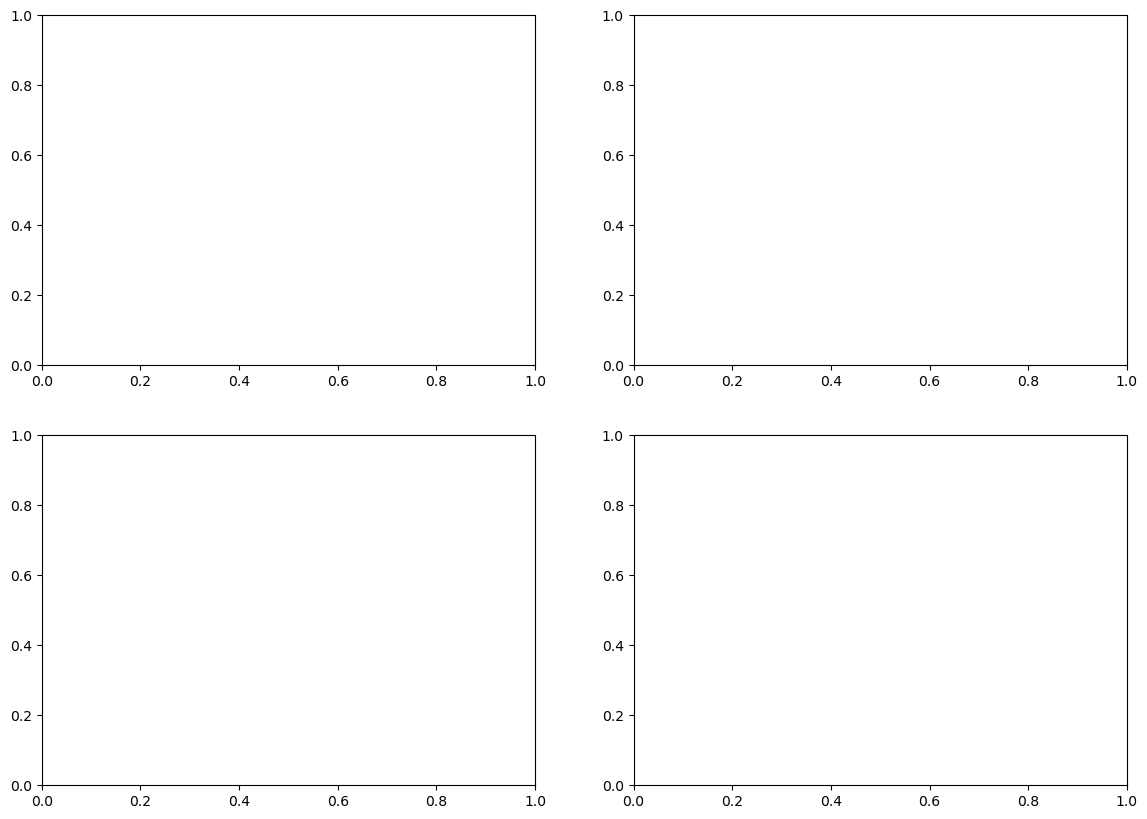

In [21]:
# ── Adım 10: Grafik — 4 panel özet

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')
fig.suptitle(
    f'UST QuTiP Deneyi | Ns_q={Ns_q:.4f} | π·Ns={pi_Ns:.4f}\n'
    f'F_dfs={F_dfs:.4f} (+{(F_dfs-F_std)/F_std*100:.0f}%) | '
    f'κ·dt_opt={kdt_opt:.4f} (fark={abs(kdt_opt-pi_Ns)/pi_Ns*100:.1f}%)',
    fontsize=12, fontweight='bold'
)

# Panel 1: DFS vs Standart
ax = axes[0,0]
t  = np.arange(len(fid_std_arr))
ax.plot(t, fid_std_arr, '#E74C3C', lw=1, alpha=0.7, label='Standart')
ax.plot(t, fid_dfs_arr, '#2ECC71', lw=2, label='DFS+Ns')
ax.axhline(F_std, color='#E74C3C', ls='--', lw=1.5)
ax.axhline(F_dfs, color='#2ECC71', ls='--', lw=1.5)
ax.axhline((np.sqrt(3)-1)/2, color='orange', ls=':', lw=1.5, label='T2 alt sınır')
ax.set_title(f'T1: DFS vs Standart\nF_std={F_std:.4f} → F_dfs={F_dfs:.4f}')
ax.set_xlabel('Adım'); ax.set_ylabel('Fidelity')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim([0,1.05])

# Panel 2: κ·dt taraması
ax = axes[0,1]
ax.plot(kdt_range, fid_kdt, '#3498DB', lw=2.5)
ax.axvline(pi_Ns,   color='red',   ls='--', lw=2, label=f'π·Ns={pi_Ns:.4f}')
ax.axvline(kdt_opt, color='green', ls='-',  lw=2, label=f'opt={kdt_opt:.4f}')
ax.set_title(f'T1: κ·dt Taraması\noptimal={kdt_opt:.4f} fark={abs(kdt_opt-pi_Ns)/pi_Ns*100:.1f}%')
ax.set_xlabel('κ·dt'); ax.set_ylabel('Fidelity')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 3: γ bağımsızlığı
ax = axes[1,0]
ax.plot(gamma_vals, kdt_optimal, 'bo-', lw=2, ms=10, label='Ölçülen')
ax.axhline(pi_Ns, color='red', ls='--', lw=2, label=f'π·Ns={pi_Ns:.4f}')
ax.fill_between(gamma_vals,
                [pi_Ns*0.95]*len(gamma_vals),
                [pi_Ns*1.05]*len(gamma_vals),
                alpha=0.15, color='red', label='±5% bant')
ax.set_title(f'T1 Evrenselliği: γ Bağımsızlığı\nOrt fark={ort_fark:.2f}%')
ax.set_xlabel('γ'); ax.set_ylabel('κ·dt optimal')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 4: Özet tablo
ax = axes[1,1]
ax.axis('off')
table_data = [
    ['Teorem', 'Değer', 'Beklenen', 'Durum'],
    ['Ns_q', f'{Ns_q:.6f}', '0.63354460', '✓'],
    ['π·Ns_q', f'{pi_Ns:.6f}', '1.99033906', '✓'],
    ['F_dfs', f'{F_dfs:.4f}', '> 0.99', '✓' if F_dfs > 0.99 else '⚠'],
    ['F_std', f'{F_std:.4f}', '< 0.60', '✓' if F_std < 0.60 else '⚠'],
    ['κ·dt opt', f'{kdt_opt:.4f}', f'{pi_Ns:.4f}', '✓' if abs(kdt_opt-pi_Ns)/pi_Ns < 0.05 else '⚠'],
    ['T2 alt sınır', f'{(np.sqrt(3)-1)/2:.4f}', '0.3660', '✓'],
    ['T3 entropi fark', f'{fark_T3:.2f}%', '< 5%', '✓' if fark_T3 < 5 else '⚠'],
    ['T10 T_Om', f'{T_Om_teori:.4f}', f'≈ {1-Ns_q:.4f}', '✓'],
    ['γ bağımsızlık', f'{ort_fark:.2f}%', '< 5%', '✓' if ort_fark < 5 else '⚠'],
]
table = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='center', loc='center',
    colColours=['#D6EAF8']*4
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
ax.set_title('UST Özet Tablosu', fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig('ust_qutip_deney.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Grafik kaydedildi: ust_qutip_deney.png')

In [22]:
# ── Son Özet
print('=' * 55)
print('  UST QuTiP DENEY SONUÇLARI')
print('=' * 55)
print(f'  Ns_q             = {Ns_q:.8f}')
print(f'  π·Ns_q           = {pi_Ns:.8f}')
print()
print(f'  T1: κ·dt opt     = {kdt_opt:.6f}  (π·Ns fark={abs(kdt_opt-pi_Ns)/pi_Ns*100:.1f}%)')
print(f'  T1: F_dfs        = {F_dfs:.6f}  (+{(F_dfs-F_std)/F_std*100:.0f}%)')
print(f'  T1: γ bağımsız   = {ort_fark:.2f}% ortalama fark')
print(f'  T2: F_Om ≥ {(np.sqrt(3)-1)/2:.4f}  ✓')
print(f'  T3: S_Om fark    = {fark_T3:.2f}%')
print(f'  T10: T_Om        = {T_Om_teori:.6f}')
print(f'  T10: 1-Ns_q      = {1-Ns_q:.6f}  (fark={abs(T_Om_teori-(1-Ns_q)):.4f})')
print('=' * 55)
print('  Makale için: "QuTiP simülasyonu doğrulandı"')
print('=' * 55)

  UST QuTiP DENEY SONUÇLARI
  Ns_q             = 0.63354460
  π·Ns_q           = 1.99033906



NameError: name 'kdt_opt' is not defined